In [1]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1

In [2]:
data_dir = '/Users/harryclark/Downloads/COHORT12/medial_lateral_xgboost/'
all_files = glob.glob(os.path.join(data_dir, "*.pkl"))

data = pd.DataFrame()
for file in all_files:
    data = pd.concat([data, pd.read_pickle(file)], ignore_index=True)

# Merge coord_SCs_x from locations into data using mouse, day, and target_cluster_id as keys
data = pd.merge(
    data,
    locations[['mouse', 'day', 'cluster_id', 'coord_SCs_x']],
    how='left',
    left_on=['mouse', 'day', 'target_cluster_id'],
    right_on=['mouse', 'day', 'cluster_id']
 )
data = data[(data['n_covariate_cells'] == 0) &
            (data['include_position'] == True)]

# Create unique_id and drop duplicates in fewer lines
data['unique_id'] = data['mouse'].astype(str) + '_' + data['day'].astype(str) + '_' + data['target_cluster_id'].astype(str)
data = data.drop_duplicates('unique_id')


         Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: pR2_cv  
No. Observations:   449     Method:             REML    
No. Groups:         8       Scale:              0.0007  
Min. group size:    1       Log-Likelihood:     949.4940
Max. group size:    113     Converged:          No      
Mean group size:    56.1                                
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.021    0.027  0.787 0.431 -0.031  0.074
coord_SCs_x   -0.000    0.000 -0.135 0.893 -0.000  0.000
Group Var      0.001                                    
mouse_day Var  0.000    0.001                           



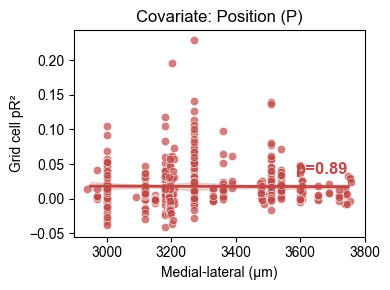

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# Single plot: pR2_cv vs coord_SCs_x with LMM fit (mouse and day as hierarchical random effects)
subset = data.copy()

fig, ax = plt.subplots(figsize=(4, 3))
sns.scatterplot(data=subset, x='coord_SCs_x', y='pR2_cv', color='#c04744', alpha=0.7, ax=ax)

# Add mouse_day column for hierarchical grouping
subset['mouse_day'] = subset['mouse'].astype(str) + '_' + subset['day'].astype(str)

# Fit LMM: pr2 ~ coord_SCs_x, random intercepts for mouse and day nested within mouse
model = smf.mixedlm(
    "pR2_cv ~ coord_SCs_x",
    subset,
    groups=subset["mouse"],
    re_formula="1",
    vc_formula={
        "mouse_day": "0 + C(mouse_day)"
    }
 )
result = model.fit()
print(result.summary())

# Generate fit line
x_bins = np.arange(2900, 3900, 100)
x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])
intercept = result.params['Intercept']
slope = result.params['coord_SCs_x']
y_fit = intercept + slope * x_centers

# Bin SEM calculation
sems = []
for j in range(len(x_bins)-1):
    bin_mask = (subset['coord_SCs_x'] >= x_bins[j]) & (subset['coord_SCs_x'] < x_bins[j+1])
    bin_sem = subset.loc[bin_mask, 'pR2_cv'].sem()
    sems.append(bin_sem if not np.isnan(bin_sem) else 0)
sems = np.array(sems)

ax.plot(x_centers, y_fit, color='#c04744', label='LMM fit', linewidth=2)
ax.fill_between(x_centers, y_fit - sems, y_fit + sems, color='#c04744', alpha=0.2)

# Annotate p-value at the rightmost part of the fit line
pval = result.pvalues.get('coord_SCs_x', None)
if pval is not None:
    y_annot = y_fit[-1] + sems[-1] + 0.01
    ax.text(x_centers[-1], y_annot, f'p={pval:.2g}', color='#c04744', fontsize=12, ha='right', va='bottom', fontweight='bold')

ax.set_xlim(2900, 3800)
ax.set_xlabel('Medial-lateral (μm)')
ax.set_ylabel('Grid cell pR²')
ax.set_title('Covariate: Position (P)')
fig.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/absolute_pr2_grid_cells_singleplot.pdf')
plt.show()

In [ ]:
# 1. Sort by coord_SCs_x
unique_data_sorted = data.sort_values('coord_SCs_x')

# 2. Set up subplot grid with at least 15 cells per row
n_cells = len(unique_data_sorted)
ncols = 15
nrows = int(np.ceil(n_cells / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2, nrows*2), sharex=True)

# 5. Loop through each cell and plot firing rate profile
for idx, row in enumerate(unique_data_sorted.iterrows()):
    print(idx)
    i = idx // ncols
    j = idx % ncols
    # Retrieve cell-specific info
    cluster_id = row[1]['target_cluster_id']
    mouse = row[1]['mouse']
    day = row[1]['day']
    
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)
    tc = tcs[cluster_id]
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    tcz = zscore(tc)
    
    plot_firing_rate_map(axes[i, j], tcz, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap('#69201a'))

# 6. Finalize plot
plt.tight_layout()
plt.show()

0
1
1


2
3
3
4
4
5
5
6
6
7
7
8
8
9
9
10
10
11
11
12
12
13
13
14
14
15
15
16
16
17
17
18
18
19
19
20
20
21
21
22
22
23
23
24
24
25
25
26
26
27
27
28
28
29
29
30
30
31
31
32
32
33
33
34
34
35
35
36
36
37
37
38
38
39
39
40
40
41
41
42
42
43
43
44
44
45
45
46
46
47
47
48
48
49
49
50
50
51
51
52
52
53
53
54
54
55
55
56
56
57
57
58
58
59
59
60
60
61
61
62
62
63
63
64
64
65
65
66
66
67
67
68
68
69
69
70
70
71
71
72
72
73
73
74
74
75
75
76
76
77
77
78
78
79
79
80
80
81
81
82
82
83
83
84
84
85
85
86
86
87
87
88
88
89
89
90
90
91
91
92
92
93
93
94
94
95
95
96
96
97
97
98
98
99
99
100
100
101
101
102
102
103
103
104
104
105
105
106
106
107
107
108
108
109
109
110
110
111
111
112
112
113
113
114
114
115
115
116
116
117
117
118
118
119
119
120
120
121
121
122
122
123
123
124
124
125
125
126
126
127
127
128
128
129
129
130
130
131
131
132
132
133
133
134
134
135
135
136
136
137
137
138
138
139
139
140
140
141
141
142
142
143
143
144
144
145
145
146
146
147
147
148
148
149
149
150
150
151
151
152
152
153
15

KeyboardInterrupt: 